In [1]:
import sys

print(sys.executable)

/Users/imseoyeong/Desktop/east-coast-job-market-analysis/.venv/bin/python3


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start_path):
    """Find the project folder containing the .git directory."""
    start_path = Path(start_path).resolve()

    for folder in [start_path, *start_path.parents]:
        if (folder / ".git").exists():
            return folder

    raise FileNotFoundError("Could not find the project root folder.")


PROJECT_ROOT = find_project_root(Path.cwd())
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
VISUALIZATION_DIR = PROJECT_ROOT / "visualizations"

VISUALIZATION_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data folder:", PROCESSED_DATA_DIR)

Project root: /Users/imseoyeong/Desktop/east-coast-job-market-analysis
Processed data folder: /Users/imseoyeong/Desktop/east-coast-job-market-analysis/data/processed


In [4]:
processed_files = sorted(
    PROCESSED_DATA_DIR.glob("adzuna_jobs_cleaned_*.csv")
)

if not processed_files:
    raise FileNotFoundError(
        "No cleaned Adzuna CSV files were found."
    )

latest_cleaned_file = processed_files[-1]

jobs = pd.read_csv(
    latest_cleaned_file,
    parse_dates=[
        "created",
        "collected_at_utc",
    ],
)

print("Loaded file:", latest_cleaned_file.name)
print("Dataset shape:", jobs.shape)
print("Unique job IDs:", jobs["job_id"].nunique())

Loaded file: adzuna_jobs_cleaned_20260804_2023.csv
Dataset shape: (437, 36)
Unique job IDs: 437


In [5]:
flag_columns = [
    "target_role_flag",
    "confirmed_early_career_flag",
    "potential_early_career_flag",
    "accessible_confirmed_early_career_flag",
    "clearance_flag",
    "citizenship_flag",
    "restricted_access_flag",
]

for column in flag_columns:
    if column not in jobs.columns:
        continue

    if not pd.api.types.is_bool_dtype(jobs[column]):
        jobs[column] = (
            jobs[column]
            .astype(str)
            .str.strip()
            .str.lower()
            .map(
                {
                    "true": True,
                    "false": False,
                }
            )
        )

jobs[flag_columns].dtypes

target_role_flag                          bool
confirmed_early_career_flag               bool
potential_early_career_flag               bool
accessible_confirmed_early_career_flag    bool
clearance_flag                            bool
citizenship_flag                          bool
restricted_access_flag                    bool
dtype: object

In [6]:
target_jobs = jobs.loc[
    jobs["target_role_flag"]
].copy()

print("All collected postings:", len(jobs))
print("Target analytics postings:", len(target_jobs))
print(
    "Excluded or adjacent postings:",
    len(jobs) - len(target_jobs),
)

All collected postings: 437
Target analytics postings: 408
Excluded or adjacent postings: 29


In [7]:
role_counts = (
    target_jobs["role_category"]
    .value_counts()
    .rename_axis("role_category")
    .reset_index(name="job_count")
)

role_counts["percent"] = (
    role_counts["job_count"]
    / len(target_jobs)
    * 100
).round(1)

role_counts

,role_category,job_count,percent
0,BI and Reporting,103,25.2
1,Data Analytics,97,23.8
2,Business and Operations,92,22.5
3,Marketing and Insights,82,20.1
4,Financial and Risk Analytics,30,7.4
5,Data Science,4,1.0


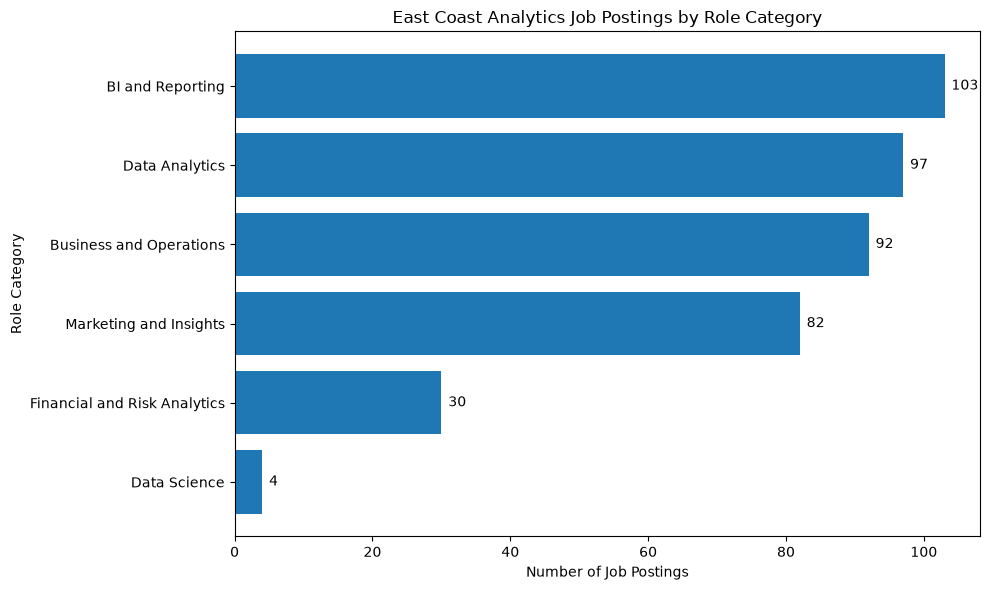

Saved to: /Users/imseoyeong/Desktop/east-coast-job-market-analysis/visualizations/job_postings_by_role_category.png


In [8]:
role_plot_data = role_counts.sort_values(
    "job_count",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    role_plot_data["role_category"],
    role_plot_data["job_count"],
)

ax.set_title(
    "East Coast Analytics Job Postings by Role Category"
)
ax.set_xlabel("Number of Job Postings")
ax.set_ylabel("Role Category")

for index, value in enumerate(
    role_plot_data["job_count"]
):
    ax.text(
        value + 1,
        index,
        str(value),
        va="center",
    )

plt.tight_layout()

output_path = (
    VISUALIZATION_DIR
    / "job_postings_by_role_category.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", output_path)

### Key Finding

BI and Reporting had the largest number of postings, followed by Data Analytics and Business and Operations. Marketing and Insights also represented a substantial share of the collected jobs.

Data Science had relatively few postings because the data-collection queries primarily targeted analyst roles rather than the broader data science job market. Therefore, this chart represents the distribution within the selected search terms, not the entire East Coast employment market.

In [10]:
jobs[
    [
        "location",
        "location_area",
        "matched_query_states",
    ]
].head(20)

,location,location_area,matched_query_states
0,"Washington, D.C., US","US | Washington, D.C.",DC
1,"Washington, D.C., US","US | Washington, D.C.",DC
2,"Annapolis Junction, Anne Arundel County",US | Maryland | Anne Arundel County | Annapoli...,MD
3,"Annapolis, Anne Arundel County",US | Maryland | Anne Arundel County | Annapolis,MD
4,"Annapolis, Anne Arundel County",US | Maryland | Anne Arundel County | Annapolis,MD
5,"Annapolis Junction, Anne Arundel County",US | Maryland | Anne Arundel County | Annapoli...,MD
6,"Derwood, Montgomery County",US | Maryland | Montgomery County | Derwood,MD
7,"Uptown, Hudson County",US | New Jersey | Hudson County | Uptown,NJ
8,"Capitol, Richmond",US | Virginia | Richmond County | Richmond | C...,VA
9,"Capitol, Richmond",US | Virginia | Richmond County | Richmond | C...,VA


In [11]:
REGION_NAMES = {
    "new york": "NY",
    "new jersey": "NJ",
    "virginia": "VA",
    "maryland": "MD",
    "district of columbia": "DC",
    "washington, d.c.": "DC",
    "washington dc": "DC",
}


def assign_analysis_region(row):
    """
    Assign one analysis region using the actual location first,
    then use the original search region as a fallback.
    """
    location_text = " | ".join(
        [
            str(row.get("location_area", "")),
            str(row.get("location", "")),
        ]
    ).lower()

    for location_name, state_code in REGION_NAMES.items():
        if location_name in location_text:
            return state_code

    matched_states = [
        state.strip()
        for state in str(
            row.get("matched_query_states", "")
        ).split("|")
        if state.strip()
    ]

    if len(matched_states) == 1:
        return matched_states[0]

    return "Unclear"


jobs["analysis_region"] = jobs.apply(
    assign_analysis_region,
    axis=1,
)

jobs["analysis_region"].value_counts(dropna=False)

analysis_region
VA    116
MD     98
NJ     93
NY     85
DC     45
Name: count, dtype: int64

In [12]:
target_jobs = jobs.loc[
    jobs["target_role_flag"]
].copy()

print(
    target_jobs["analysis_region"]
    .value_counts(dropna=False)
)

analysis_region
VA    111
NJ     91
MD     82
NY     82
DC     42
Name: count, dtype: int64


In [13]:
region_order = [
    "NY",
    "NJ",
    "DC",
    "VA",
    "MD",
]

region_counts = (
    target_jobs.loc[
        target_jobs["analysis_region"].isin(region_order)
    ]
    .groupby("analysis_region")
    .size()
    .reindex(region_order, fill_value=0)
    .rename("job_count")
    .reset_index()
)

region_counts["percent"] = (
    region_counts["job_count"]
    / region_counts["job_count"].sum()
    * 100
).round(1)

region_counts

,analysis_region,job_count,percent
0,NY,82,20.1
1,NJ,91,22.3
2,DC,42,10.3
3,VA,111,27.2
4,MD,82,20.1


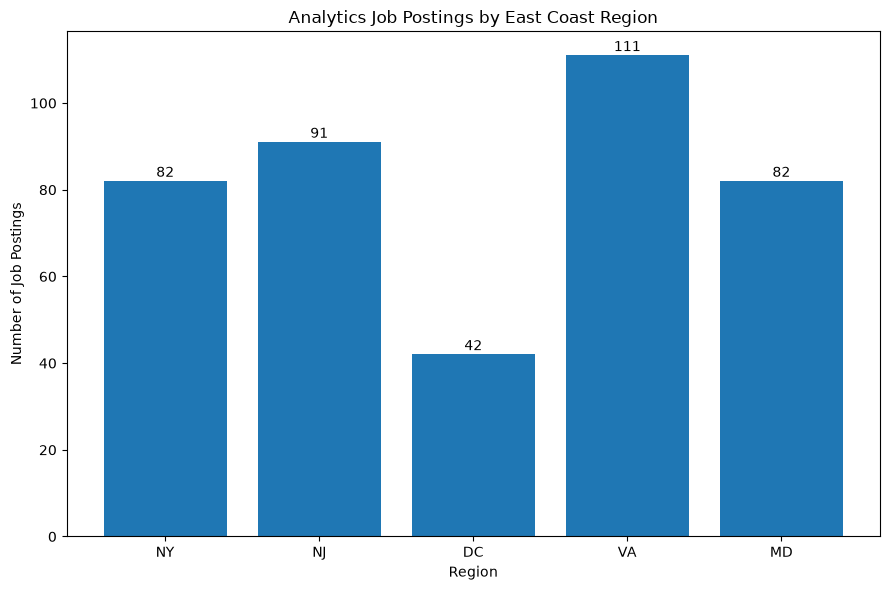

Saved to: /Users/imseoyeong/Desktop/east-coast-job-market-analysis/visualizations/job_postings_by_region.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(
    region_counts["analysis_region"],
    region_counts["job_count"],
)

ax.set_title(
    "Analytics Job Postings by East Coast Region"
)
ax.set_xlabel("Region")
ax.set_ylabel("Number of Job Postings")

for index, value in enumerate(
    region_counts["job_count"]
):
    ax.text(
        index,
        value + 1,
        str(value),
        ha="center",
    )

plt.tight_layout()

region_output_path = (
    VISUALIZATION_DIR
    / "job_postings_by_region.png"
)

fig.savefig(
    region_output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", region_output_path)

### Key Finding

Virginia had the largest number of analytics-related postings in the collected dataset, followed by New Jersey. New York and Maryland had the same number of postings, while Washington, D.C. had the fewest.

These counts represent the postings returned under the selected search terms and API collection limits. Therefore, they should be interpreted as differences within the collected sample rather than a complete measure of each region's job market.

In [15]:
region_summary = (
    target_jobs.loc[
        target_jobs["analysis_region"].isin(region_order)
    ]
    .groupby("analysis_region")
    .agg(
        total_analytics_jobs=("job_id", "count"),
        confirmed_early_career=(
            "confirmed_early_career_flag",
            "sum",
        ),
        potential_early_career=(
            "potential_early_career_flag",
            "sum",
        ),
        accessible_confirmed=(
            "accessible_confirmed_early_career_flag",
            "sum",
        ),
        restricted_jobs=(
            "restricted_access_flag",
            "sum",
        ),
    )
    .reindex(region_order)
    .reset_index()
)

region_summary["confirmed_rate_percent"] = (
    region_summary["confirmed_early_career"]
    / region_summary["total_analytics_jobs"]
    * 100
).round(1)

region_summary["restricted_rate_percent"] = (
    region_summary["restricted_jobs"]
    / region_summary["total_analytics_jobs"]
    * 100
).round(1)

region_summary

,analysis_region,total_analytics_jobs,confirmed_early_career,potential_early_career,accessible_confirmed,restricted_jobs,confirmed_rate_percent,restricted_rate_percent
0,NY,82,6,62,6,0,7.3,0.0
1,NJ,91,8,66,8,0,8.8,0.0
2,DC,42,1,27,0,9,2.4,21.4
3,VA,111,4,79,3,26,3.6,23.4
4,MD,82,3,63,2,15,3.7,18.3


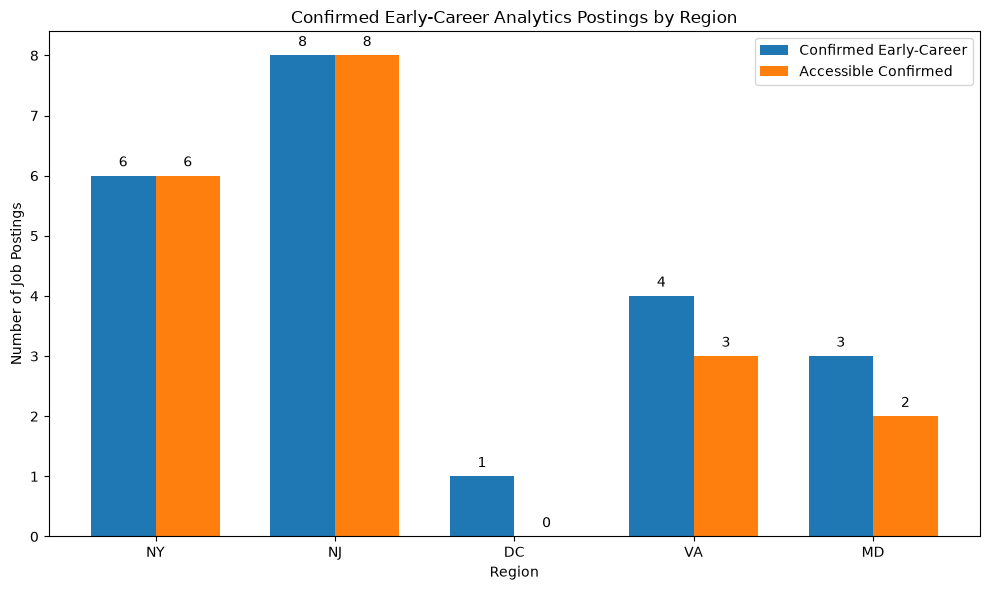

Saved to: /Users/imseoyeong/Desktop/east-coast-job-market-analysis/visualizations/early_career_postings_by_region.png


In [16]:
import numpy as np


plot_data = region_summary.copy()

x_positions = np.arange(len(plot_data))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(10, 6))

confirmed_bars = ax.bar(
    x_positions - bar_width / 2,
    plot_data["confirmed_early_career"],
    width=bar_width,
    label="Confirmed Early-Career",
)

accessible_bars = ax.bar(
    x_positions + bar_width / 2,
    plot_data["accessible_confirmed"],
    width=bar_width,
    label="Accessible Confirmed",
)

ax.set_title(
    "Confirmed Early-Career Analytics Postings by Region"
)
ax.set_xlabel("Region")
ax.set_ylabel("Number of Job Postings")
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_data["analysis_region"])
ax.legend()

for bars in [confirmed_bars, accessible_bars]:
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.1,
            str(int(height)),
            ha="center",
            va="bottom",
        )

plt.tight_layout()

early_career_output_path = (
    VISUALIZATION_DIR
    / "early_career_postings_by_region.png"
)

fig.savefig(
    early_career_output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", early_career_output_path)

### Key Finding

New Jersey had the highest number of confirmed early-career analytics postings in the collected sample, followed by New York. All confirmed postings in New Jersey and New York had no detected citizenship or security-clearance restrictions.

Washington, D.C. had only one confirmed early-career posting, and that posting contained a detected access restriction. Virginia and Maryland also had small differences between confirmed and accessible postings.

The absence of a detected restriction does not indicate visa sponsorship eligibility. It only means that the available posting text did not explicitly mention a citizenship or security-clearance requirement.

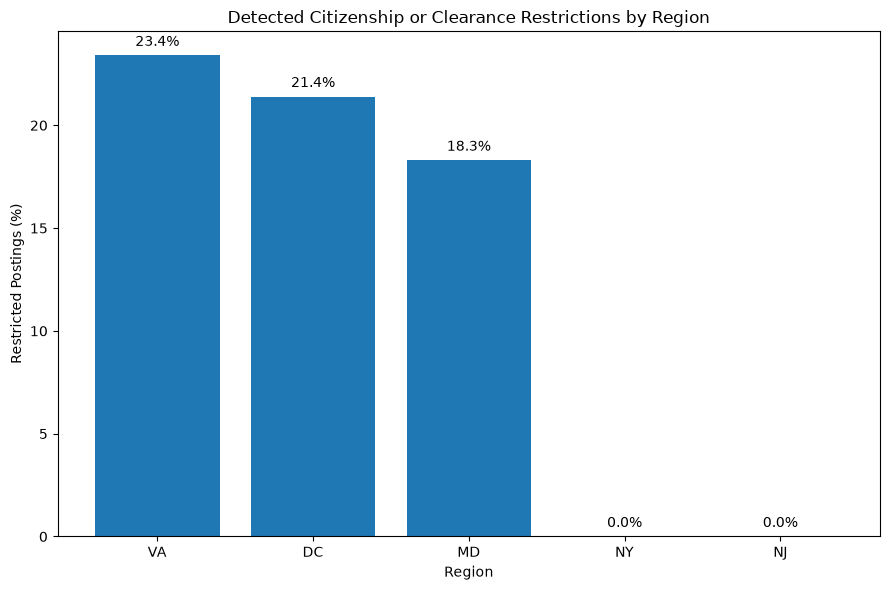

Saved to: /Users/imseoyeong/Desktop/east-coast-job-market-analysis/visualizations/restriction_rate_by_region.png


In [17]:
restriction_plot_data = region_summary.sort_values(
    "restricted_rate_percent",
    ascending=False,
)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    restriction_plot_data["analysis_region"],
    restriction_plot_data["restricted_rate_percent"],
)

ax.set_title(
    "Detected Citizenship or Clearance Restrictions by Region"
)
ax.set_xlabel("Region")
ax.set_ylabel("Restricted Postings (%)")

for bar, rate in zip(
    bars,
    restriction_plot_data["restricted_rate_percent"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()

restriction_output_path = (
    VISUALIZATION_DIR
    / "restriction_rate_by_region.png"
)

fig.savefig(
    restriction_output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", restriction_output_path)

### Key Finding

Virginia had the highest detected rate of citizenship or security-clearance restrictions, followed by Washington, D.C. and Maryland. No such restrictions were detected in the available text for New York or New Jersey postings.

These values reflect keyword detection in the job descriptions returned by the API. A 0% detection rate does not prove that every posting in the region is open to international applicants, and the absence of a restriction does not indicate visa sponsorship.

In [18]:
import re


SKILL_PATTERNS = {
    "SQL": r"\bsql\b",
    "Python": r"\bpython\b",
    "Microsoft Excel": r"\bexcel\b|microsoft excel",
    "Tableau": r"\btableau\b",
    "Power BI": r"\bpower\s*bi\b",
    "R": r"(?<![a-z0-9])r(?![a-z0-9])|\br programming\b",
    "SAS": r"\bsas\b",
    "Java": r"\bjava\b",
    "Git": r"\bgit\b|\bgithub\b",
    "AWS": r"\baws\b|amazon web services",
    "Azure": r"\bazure\b",
    "Google Cloud": r"\bgcp\b|google cloud",
    "Snowflake": r"\bsnowflake\b",
    "Spark": r"\bapache spark\b|\bpyspark\b|\bspark\b",
    "Machine Learning": r"\bmachine learning\b",
    "Statistics": r"\bstatistics?\b|\bstatistical\b",
    "ETL": r"\betl\b|extract[,\s]+transform[,\s]+load",
}


def extract_skills(description):
    """Return detected skills from a job description."""
    text = str(description).lower()

    return [
        skill
        for skill, pattern in SKILL_PATTERNS.items()
        if re.search(pattern, text, flags=re.IGNORECASE)
    ]


target_jobs["detected_skills"] = (
    target_jobs["description"].apply(extract_skills)
)

target_jobs[
    ["title", "company", "detected_skills"]
].head(10)

,title,company,detected_skills
10,BI Analyst II,Indeed,[]
11,Business Intelligence Analyst,Eliassen Group,[]
12,Business Intelligence Analyst II,Howard University Hospital,[]
13,"Business Intelligence Engineer, Intelligent Ta...",Amazon,[]
14,Chief Enterprise Architect (Business Intellige...,BTI,[]
15,Chief Enterprise Architect (Business Intellige...,BTI,[]
16,Chief Enterprise Business Architect (Business ...,BTI,[]
17,Chief Enterprise Business Architect (Business ...,BTI,[]
18,REMOTE Default Reporting and Analytics Analyst,Carrington,[R]
19,Remote Investor Reporting Analyst,Carrington,[]


In [35]:
SKILL_PATTERNS = {
    "SQL": (
        r"\bsql\b|\bt-sql\b|\bpl/sql\b|"
        r"\bmysql\b|\bpostgresql\b",
        re.IGNORECASE,
    ),
    "Python": (
        r"\bpython\b|\bpandas\b|\bnumpy\b",
        re.IGNORECASE,
    ),
    "Microsoft Excel": (
        r"\b(?:microsoft\s+|ms\s+)?excel\b|"
        r"\bpivot\s+tables?\b|\bvlookup\b|\bxlookup\b",
        re.IGNORECASE,
    ),
    "Tableau": (
        r"\btableau\b",
        re.IGNORECASE,
    ),
    "Power BI": (
        r"\bpower\s*bi\b|\bpowerbi\b",
        re.IGNORECASE,
    ),
    "R": (
        r"\brstudio\b|\br programming\b|"
        r"\bprogramming (?:language )?r\b|"
        r"\busing r\b|"
        r"(?<![A-Za-z0-9])R(?![A-Za-z0-9]| ?& ?D)",
        0,
    ),
    "SAS": (
        r"\bsas\b",
        re.IGNORECASE,
    ),
    "SPSS": (
        r"\bspss\b",
        re.IGNORECASE,
    ),
    "Java": (
        r"\bjava\b",
        re.IGNORECASE,
    ),
    "Git": (
        r"\bgit\b|\bgithub\b|\bversion control\b",
        re.IGNORECASE,
    ),
    "AWS": (
        r"\baws\b|\bamazon web services\b",
        re.IGNORECASE,
    ),
    "Azure": (
        r"\bazure\b",
        re.IGNORECASE,
    ),
    "Google Cloud": (
        r"\bgcp\b|\bgoogle cloud\b",
        re.IGNORECASE,
    ),
    "Snowflake": (
        r"\bsnowflake\b",
        re.IGNORECASE,
    ),
    "Spark": (
        r"\bapache spark\b|\bpyspark\b|\bspark\b",
        re.IGNORECASE,
    ),
    "Machine Learning": (
        r"\bmachine learning\b",
        re.IGNORECASE,
    ),
    "Statistics": (
        r"\bstatistics?\b|\bstatistical\b",
        re.IGNORECASE,
    ),
    "ETL": (
        r"\betl\b|"
        r"\bextract[,\s]+transform[,\s]+load\b",
        re.IGNORECASE,
    ),
    "Alteryx": (
        r"\balteryx\b",
        re.IGNORECASE,
    ),
    "Looker": (
        r"\blooker\b",
        re.IGNORECASE,
    ),
    "Qlik": (
        r"\bqlik\b|\bqlikview\b|\bqlik sense\b",
        re.IGNORECASE,
    ),
}


def extract_skills(row):
    """Detect skills in both the job title and description."""
    combined_text = (
        f"{row.get('title', '')} "
        f"{row.get('description', '')}"
    )

    detected = []

    for skill, (pattern, flags) in SKILL_PATTERNS.items():
        if re.search(pattern, combined_text, flags=flags):
            detected.append(skill)

    return detected


target_jobs["detected_skills"] = target_jobs.apply(
    extract_skills,
    axis=1,
)

In [36]:
skill_counts = (
    target_jobs["detected_skills"]
    .explode()
    .dropna()
    .value_counts()
    .rename_axis("skill")
    .reset_index(name="job_count")
)

skill_counts["percent_of_postings"] = (
    skill_counts["job_count"]
    / len(target_jobs)
    * 100
).round(1)

skill_counts

,skill,job_count,percent_of_postings
0,SQL,14,3.4
1,Power BI,11,2.7
2,Tableau,5,1.2
3,Statistics,5,1.2
4,Python,4,1.0
5,Spark,3,0.7
6,Microsoft Excel,3,0.7
7,ETL,3,0.7
8,R,2,0.5
9,Machine Learning,2,0.5


In [24]:
target_jobs["description_word_count"] = (
    target_jobs["description"]
    .fillna("")
    .str.split()
    .str.len()
)

print(
    "Median description word count:",
    target_jobs["description_word_count"].median(),
)

print(
    "Postings with no detected skills:",
    target_jobs["detected_skills"]
    .str.len()
    .eq(0)
    .sum(),
)

target_jobs["description_word_count"].describe()

Median description word count: 72.0
Postings with no detected skills: 368


count    408.000000
mean      72.247549
std        6.330768
min       36.000000
25%       69.000000
50%       72.000000
75%       76.000000
max       91.000000
Name: description_word_count, dtype: float64

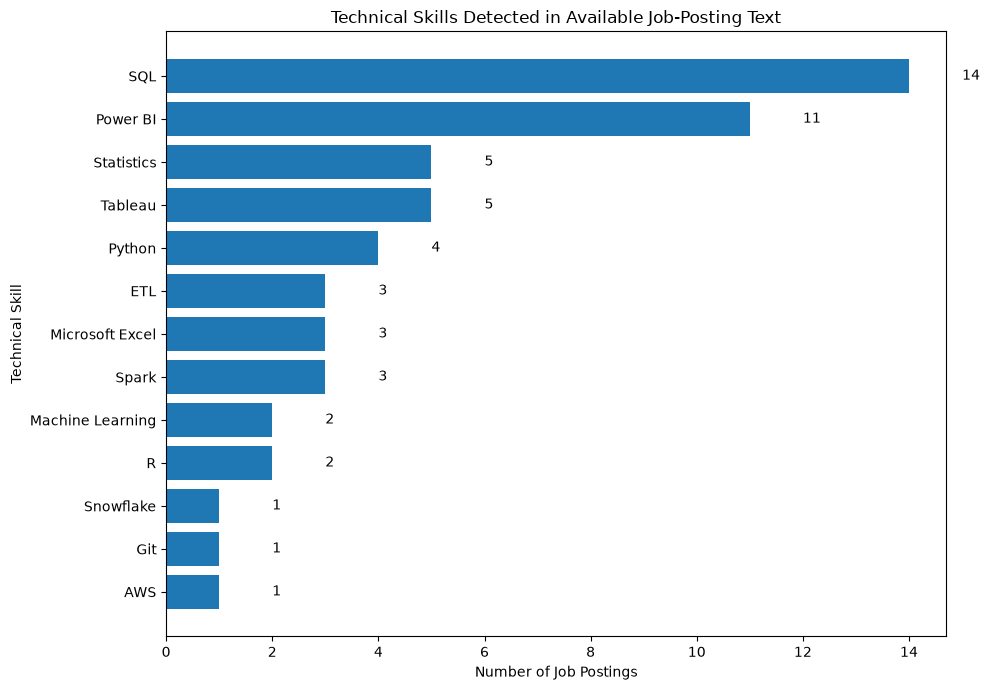

Saved to: /Users/imseoyeong/Desktop/east-coast-job-market-analysis/visualizations/most_requested_technical_skills.png


In [29]:
top_skills = (
    skill_counts
    .sort_values("job_count", ascending=False)
    .head(15)
    .sort_values("job_count", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top_skills["skill"],
    top_skills["job_count"],
)

ax.set_title(
    "Most Frequently Requested Technical Skills"
)
ax.set_xlabel("Number of Job Postings")
ax.set_ylabel("Technical Skill")

for bar, value in zip(
    bars,
    top_skills["job_count"],
):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center",
    )

plt.tight_layout()

skills_output_path = (
    VISUALIZATION_DIR
    / "most_requested_technical_skills.png"
)

fig.savefig(
    skills_output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", skills_output_path)

### Key Finding

SQL was the most frequently detected technical skill, followed by Power BI. Tableau, statistics, and Python appeared less frequently in the available posting text.

However, at least one tracked technical skill was detected in only 40 of the 408 target analytics postings. The median description contained approximately 72 words, indicating that the API frequently returned shortened job-description excerpts. Therefore, these values should be interpreted as detected keyword mentions rather than a complete measure of employer skill requirements.

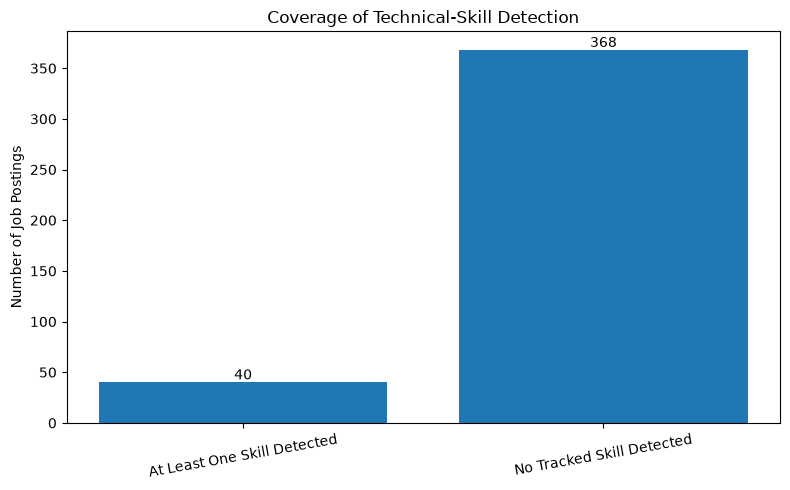

Saved to: /Users/imseoyeong/Desktop/east-coast-job-market-analysis/visualizations/technical_skill_detection_coverage.png


In [41]:
skill_coverage = pd.DataFrame(
    {
        "coverage": [
            "At Least One Skill Detected",
            "No Tracked Skill Detected",
        ],
        "job_count": [
            target_jobs["detected_skills"].str.len().gt(0).sum(),
            target_jobs["detected_skills"].str.len().eq(0).sum(),
        ],
    }
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    skill_coverage["coverage"],
    skill_coverage["job_count"],
)

ax.set_title("Coverage of Technical-Skill Detection")
ax.set_xlabel("")
ax.set_ylabel("Number of Job Postings")
ax.tick_params(axis="x", rotation=10)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,
        str(int(height)),
        ha="center",
    )

plt.tight_layout()

coverage_output_path = (
    VISUALIZATION_DIR
    / "technical_skill_detection_coverage.png"
)

fig.savefig(
    coverage_output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", coverage_output_path)

In [42]:
title_counts = (
    target_jobs["title"]
    .str.strip()
    .value_counts()
    .rename_axis("job_title")
    .reset_index(name="job_count")
)

title_counts.head(15)

,job_title,job_count
0,Data Analyst,34
1,Operations System Analyst,26
2,Marketing Operations Analyst,17
3,Business Intelligence Analyst,9
4,M&D Operations Analyst Intern - OVIP,8
5,"Submarine Logistics Data Analyst, Lead",8
6,Data Analyst with Security Clearance,7
7,Operations Analyst,6
8,Financial Services - Customer Tax Operations a...,6
9,Senior Data Analyst,5


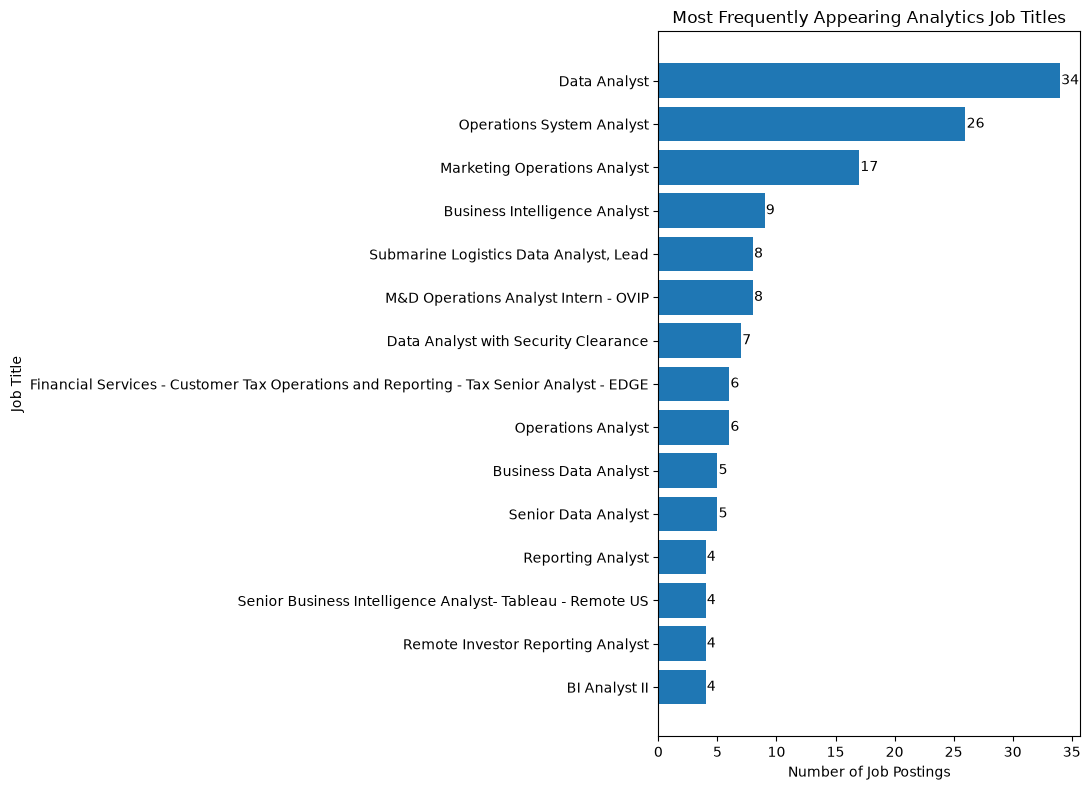

Saved to: /Users/imseoyeong/Desktop/east-coast-job-market-analysis/visualizations/most_common_job_titles.png


In [43]:
top_titles = (
    title_counts
    .head(15)
    .sort_values("job_count", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    top_titles["job_title"],
    top_titles["job_count"],
)

ax.set_title("Most Frequently Appearing Analytics Job Titles")
ax.set_xlabel("Number of Job Postings")
ax.set_ylabel("Job Title")

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        str(int(width)),
        va="center",
    )

plt.tight_layout()

titles_output_path = (
    VISUALIZATION_DIR
    / "most_common_job_titles.png"
)

fig.savefig(
    titles_output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", titles_output_path)

### Key Finding

Data Analyst was the most frequently appearing exact job title, followed by Operations System Analyst and Marketing Operations Analyst. Business Intelligence Analyst also appeared frequently.

Some repeated titles represent similar positions posted across multiple locations. In addition, the chart counts exact job-title text, so closely related titles such as Data Analyst and Business Data Analyst are shown separately.

In [44]:
category_counts = (
    target_jobs["category"]
    .fillna("Unknown")
    .value_counts()
    .rename_axis("job_category")
    .reset_index(name="job_count")
)

category_counts["percent"] = (
    category_counts["job_count"]
    / len(target_jobs)
    * 100
).round(1)

category_counts

,job_category,job_count,percent
0,IT Jobs,237,58.1
1,Accounting & Finance Jobs,82,20.1
2,"PR, Advertising & Marketing Jobs",40,9.8
3,Consultancy Jobs,10,2.5
4,Sales Jobs,9,2.2
5,Healthcare & Nursing Jobs,7,1.7
6,"Energy, Oil & Gas Jobs",6,1.5
7,Admin Jobs,4,1.0
8,Scientific & QA Jobs,4,1.0
9,Customer Services Jobs,2,0.5


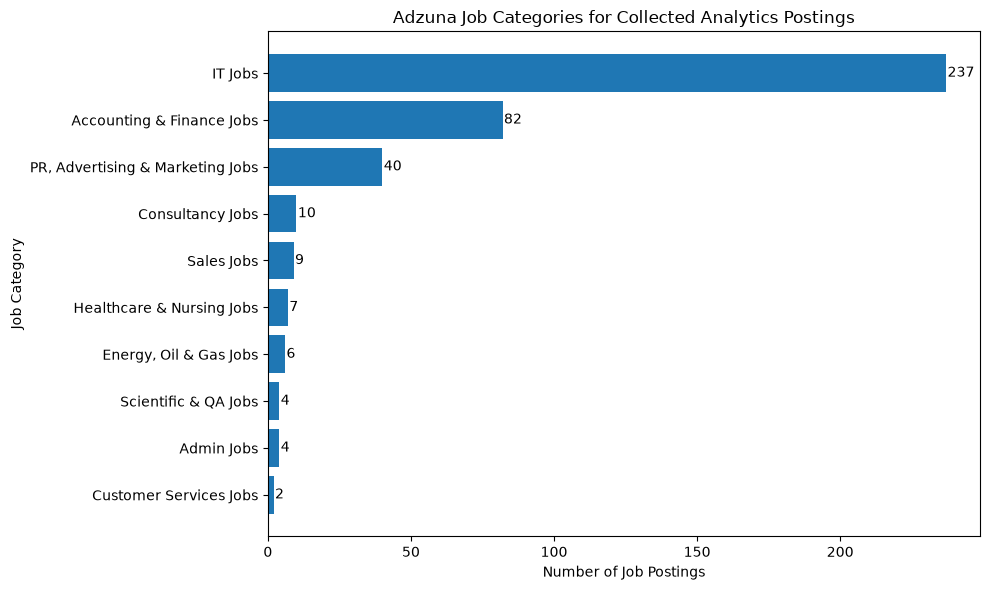

Saved to: /Users/imseoyeong/Desktop/east-coast-job-market-analysis/visualizations/job_postings_by_adzuna_category.png


In [45]:
top_categories = (
    category_counts
    .head(10)
    .sort_values("job_count", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_categories["job_category"],
    top_categories["job_count"],
)

ax.set_title(
    "Adzuna Job Categories for Collected Analytics Postings"
)
ax.set_xlabel("Number of Job Postings")
ax.set_ylabel("Job Category")

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        str(int(width)),
        va="center",
    )

plt.tight_layout()

category_output_path = (
    VISUALIZATION_DIR
    / "job_postings_by_adzuna_category.png"
)

fig.savefig(
    category_output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", category_output_path)

### Key Finding

The collected analytics postings were distributed across several broad Adzuna job categories, demonstrating that analytics work appears in multiple functional areas rather than in a single job category.

These labels are platform-defined job categories and should not be interpreted as the employing companies' formal industries. A more precise industry analysis would require additional company-level industry data.

## Overall Findings

This analysis examined 437 unique job postings collected across New York, New Jersey, Washington, D.C., Virginia, and Maryland. Of these postings, 408 were classified as target analytics roles.

The largest role category was BI and Reporting, followed by Data Analytics, Business and Operations, and Marketing and Insights. Data Analyst was the most frequently appearing exact job title.

Within the collected sample, Virginia had the largest number of analytics-related postings, followed by New Jersey. However, New Jersey and New York had the highest numbers of confirmed early-career postings without detected citizenship or security-clearance restrictions.

Citizenship or security-clearance requirements were detected most frequently in Virginia, Washington, D.C., and Maryland. No such restrictions were detected in the available posting text for New York or New Jersey.

SQL and Power BI were the most frequently detected technical skills. However, technical skills were detected in only 40 of the 408 target analytics postings because the API generally returned short job-description excerpts.

## Limitations

- The dataset represents postings returned by selected search terms and API limits rather than the complete East Coast job market.
- Each location and search-term combination returned a maximum number of results, so regional posting counts should not be interpreted as complete market-size estimates.
- The Adzuna API frequently returned shortened job-description excerpts. This limited the detection of technical skills, experience requirements, citizenship restrictions, and security-clearance requirements.
- Early-career classifications were created using job-title keywords and detected experience requirements. They should be treated as heuristic estimates rather than verified employer classifications.
- A posting without a detected citizenship or security-clearance restriction is not necessarily open to international applicants and does not indicate visa sponsorship.
- Adzuna job categories describe broad posting categories rather than the formal industries of the hiring companies.
- Exact job titles were counted separately, so closely related titles may appear as different categories.
- The results reflect postings collected during one data-collection period and may change over time.